# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

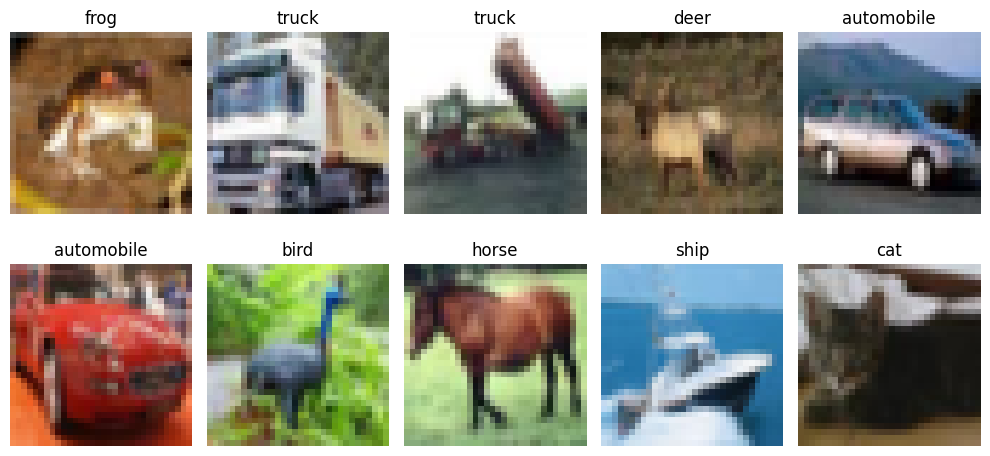

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.2746 - loss: 1.9909 - val_accuracy: 0.3310 - val_loss: 1.8549
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3223 - loss: 1.8584 - val_accuracy: 0.3672 - val_loss: 1.7660
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.3426 - loss: 1.7985 - val_accuracy: 0.3846 - val_loss: 1.7359
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3574 - loss: 1.7665 - val_accuracy: 0.3948 - val_loss: 1.7047
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3719 - loss: 1.7262 - val_accuracy: 0.3994 - val_loss: 1.6972
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.3797 - loss: 1.7097 - val_accuracy: 0.3986 - val_loss: 1.6688
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3850 - loss: 1.6960 - val_accuracy: 0.4168 - val_loss: 1.6528
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.3917 - loss: 1.6739 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4361 - loss: 1.6006
ANN Test Accuracy: 0.4361000061035156


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 112ms/step - accuracy: 0.4666 - loss: 1.4926 - val_accuracy: 0.5864 - val_loss: 1.1704
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 111ms/step - accuracy: 0.6050 - loss: 1.1333 - val_accuracy: 0.5948 - val_loss: 1.1700
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 110ms/step - accuracy: 0.6636 - loss: 0.9637 - val_accuracy: 0.4870 - val_loss: 1.5829
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 112ms/step - accuracy: 0.7049 - loss: 0.8464 - val_accuracy: 0.6550 - val_loss: 1.0359
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 111ms/step - accuracy: 0.7390 - loss: 0.7544 - val_accuracy: 0.6016 - val_loss: 1.2776
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 110ms/step - accuracy: 0.7648 - loss: 0.6722 - val_accuracy: 0.6962 - val_loss: 0.8904
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 111ms/step - accuracy: 0.7867 - loss: 0.6045 - val_accuracy: 0.7088 - val_loss: 0.9243
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 110ms/step - accuracy: 0.8088 - loss: 0

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7114 - loss: 1.0042
CNN Test Accuracy: 0.7113999724388123


## 📈 Compare Learning Curves

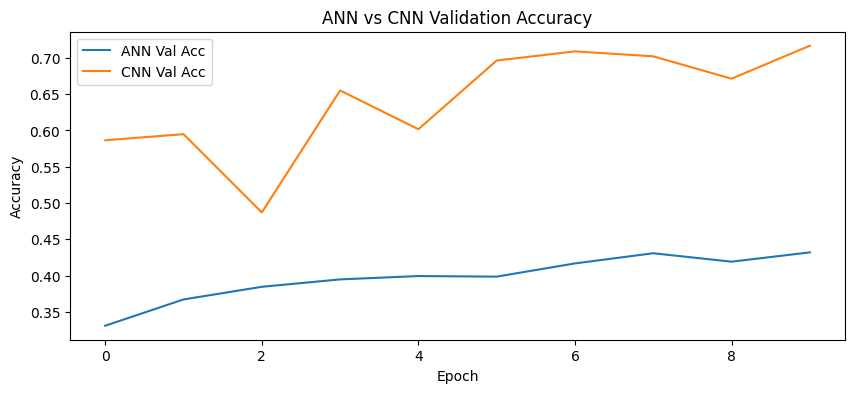

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

In [ ]:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1, batch_size=64)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 87ms/step - accuracy: 0.3570 - loss: 1.7561 - val_accuracy: 0.4896 - val_loss: 1.4031
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 85ms/step - accuracy: 0.4614 - loss: 1.5007 - val_accuracy: 0.5062 - val_loss: 1.3957
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 86ms/step - accuracy: 0.4940 - loss: 1.4125 - val_accuracy: 0.5460 - val_loss: 1.2534
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 85ms/step - accuracy: 0.5203 - loss: 1.3509 - val_accuracy: 0.5788 - val_loss: 1.1884
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 84ms/step - accuracy: 0.5372 - loss: 1.3041 - val_accuracy: 0.5914 - val_loss: 1.1330
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 86ms/step - accuracy: 0.5466 - loss: 1.2745 - val_accuracy: 0.6188 - val_loss: 1.0707
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 84ms/step - accuracy: 0.5619 - loss: 1.2417 - val_accuracy: 0.5980 - val_loss: 1.1661
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 85ms/step - accuracy: 0.5704 - loss: 1.2219 - 

In [ ]:
aug_cnn_test_loss, aug_cnn_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6227 - loss: 1.0555
Augmented CNN Test Accuracy: 0.6226999759674072


## 📈 Compare Learning Curves (with Augmented CNN)

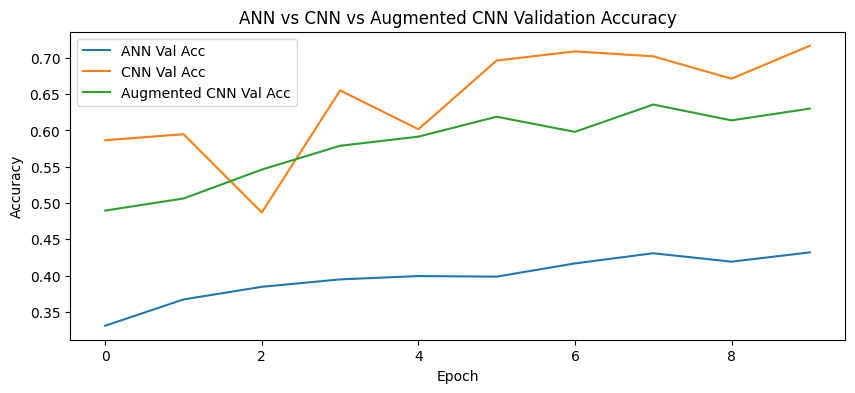

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.plot(aug_history.history['val_accuracy'], label='Augmented CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN vs Augmented CNN Validation Accuracy")
plt.legend()
plt.show()

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4361
1,CNN,0.7114


In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_cnn_test_acc]
})
display(comparison)

,Model,Test Accuracy
0,ANN,0.4361
1,CNN,0.7114
2,Augmented CNN,0.6227


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**